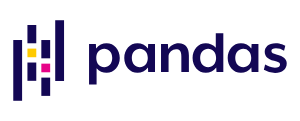





### In this tutorial we are going to work with Pandas. We will use Pandas to analyse two-dimensional data inclduing learning about data strutures, statistical analysis, and working with big and messy data.


From the Pandas docs:
    
    pandas is a Python package providing fast, flexible, and expressive data structures designed to make working with “relational” or “labeled” data both easy and intuitive. It aims to be the fundamental high-level building block for doing practical, real-world data analysis in Python. Additionally, it has the broader goal of becoming the most powerful and flexible open source data analysis/manipulation tool available in any language. It is already well on its way toward this goal.

We  `import` the module (in our environment) in the normal way.

It may be worth opening the other tutorial `002-H2-AMP-python_introduction` as a second tab so that you can refer to it.

In [ ]:
import pandas as pd

## Creating datasets with Pandas

Pandas is based around **dataframes**.

**Dataframes** are two-dimensional, size-mutable, potentially heterogeneous tabular data, kind of like an excel document.

Data frames are indexed by column and row. 

We can create dataframes quiet easily. They can be a mix of numbers and strings

In [ ]:
# create a data array
d = {'col1': [1, 2, 3, 4, 5],
     'col2': [10, 11,12,13,14]
    }

# convert to a data frome, called df
df = pd.DataFrame(data=d)

# show the data frame in a nice readable format
df


### Numpy + Pandas

We can also use Numpy arrays in Pandas dataframes.

In [ ]:
# need to import numpy
import numpy as np

# create a data array
d = {'col1': [1,2,3,4,5],
     'col2': np.array([1,2,3,4,5]),}

# convert to a data frome
df = pd.DataFrame(data=d)

# show the data frame
df


## Expanding and renaming: basics

now you have a `dataframe` you can re-model it to your own requirements.

In [ ]:
# Lets rename some of the columns
df=df.rename(columns={"col1": "Index", "col2": "Radius"})

# and change the index to the number of radius's 
df=df.set_index('Index')

df

### Adding new columns

In [ ]:
# add new colum of area of a circle
df["circle_area"] = df["Radius"] * 1.882

np.pi*df.Radius**2

df

&#x1F913;

***1.Make an dataframe with one column of numbers 1 to 50 with evenly spaced intervals of 0.1 and the second column of random numbers (radius) the same size.***

***2.Set the index to be the first column***

***3.Compute the area of the circle and volume of a spehere with same radius,  and add as a third and fourth column.***

*HINT: Think back to the Numpy random and linspace functions*

## Stats with Pandas

We can perform lots of actions on the data such as calculating the mean

In [ ]:
# the mean of the data
mean=df.mean()
print(mean)

When calcualting the mean,  it's better to specify the axis along which you want to perform the method

`axis=0` is mean of the columns, `axis=1` is mean of the rows

In [ ]:
# the columnwise mean of the data
mean=df.mean(axis=0)
print(mean)

Pandas has a nice function for printing some descriptive statistics called `describe`

In [ ]:
df.describe()

## 2. Plotting data with Pandas

Pandas plots data as well - and it's really easy

you can jsut write `df.plot()`

&#x1F913;

***Try and plot your circle data***


&#x1F913;

***Can you fill in the gaps below to create a dataframe from with data to create a sine wave, the xdata should be your evenly spaced range and the y should be your sine transformation***





In [ ]:
# create a data array
d = {'xdata': [XXXXXXX],
     'ydata': [XXXXXXXX]
    }

# convert to a data frome, called df
df = pd.DataFrame(data=d)

# tell Pandas what data we want to plot
df.plot(x='xdata',y='ydata',marker='.')

# simple!!!


&#x1F913;

***Add a third column containing the cosine of xdata and plot ydata and the new column on the same plot***

*HINT: You only use one plot function but include all yout ydata in a string array `e.g. y=['y1','y2','y3']`*

And remember you can see all your workspace variables by calling `whos` 

In [ ]:
whos

## 3. Reading data with Pandas

Reading data with Pandas is really easy. If we have an excel file, `pd.read_excel` can read those data directly into the workspace

I've added some oceanography data that we collected last year in a excel file called ***ocean_data.xlsx***

We usually call the dataframe `df` but you can call it anything you like.

We will let Pandas see if it can read the data without us telling it anything about the data. Its an `.xlxs` file so we need to use `read_excel` function


In [ ]:
# try and read the data
od=pd.read_excel('data/ocean_profile.xlsx')

# use the head option to see the first five lines
od.head(5)


Looks pretty good. Let's say we aere just interested in the Fluoresence and PAR data and as the data are from a profile, we are only really interested in the change in these parameters with pressure or depth.

In [ ]:
od=pd.read_excel('data/ocean_profile.xlsx',
                     names=["Pres","Fluor","PAR"], # tell pandas what to call our columns
                     usecols="F,I,J", # tell pandas which columns to use by listing column letters of numbers usecols=[1,2,3]
                )


# print the first 5 lines
print(od.head(5))

# plot the data
od.plot(subplots=True)


### Matplotlib is much better for plotting control

We need to import matplotlib so we can use the full library

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
fig,ax =plt.subplots(1,2)

# first subplot
od.plot(ax=ax[0],
        x="Fluor",y="Pres",
        color='g',
        legend=False)

# second subplot
od.plot(ax=ax[1],
        x="PAR",y="Pres",
        color='r',
        legend=False)

# do some nice things to the data
for axes in ax:
    axes.invert_yaxis()
    axes.grid()
    


&#x1F913;

***Can you modify the read function above to read in temperature and salinity data, print the first 30 lines, and plot them against each other?***

## Big data and time series: a bit more complex

Pandas is really good at working with time series. It can read and create time series data rally easily.

A time series is made up of dates, so let's make some!

We use `date_range` to make an array of dates

Lets make a dataframe that has `temperature`, `salinity`, and `pressure` to match the some dates

We'll pretent this is an instrument deployed at apporximately 750 m in the North Atlantic

We'll also extract some date vectors to do some analyis on.

In [ ]:
# make a range of dates over approx two years
n_obs=365*4
dates = pd.date_range("20130101", # start date
                      periods=n_obs, # how many intervals
                      freq='12h') # frequency

dates # print the result

The `dates` variable has loads of information. 

For example.....

In [ ]:
# we can get just the year
dates.year

In [ ]:
# The day of the week with Monday=0, Sunday=6.
dates.day_of_week

We are using it as an index for a time series

In [ ]:
df = pd.DataFrame({
                   'Temp':np.random.normal(4, scale=0.5,size=n_obs)+np.sin(np.linspace(np.pi,np.pi*6,n_obs)),
                    'Salinity':np.random.randn(n_obs)+35+np.sin(np.linspace(np.pi,np.pi*6,n_obs)),
                    'Pressure':np.random.randn(n_obs)+750,},
                  index=dates, 
            )

df.tail(10)

&#x1F913;

***Can you plot the Temperature data? Why have I added a sine wave, and what does it do to the data?***

***See if you can add labels and a grid***

## More stats


So we have around two years of data. Lets do some **VERY** basic stats

In [ ]:
# mean of all data
df.mean()

Doesn't tell us very much, but we could use our dates to get some more interesting means. Our dates are now called by `index`

So, to get the months, for example...

In [ ]:
df.index.month

We now use the `groupby` function to group our data by month

The line belwow groups the data by month and then plots each month as a different color

In [ ]:
df.groupby(df.index.month)['Temp'].plot(marker='.', linestyle='')
plt.legend()

&#x1F913;

***Can you plot mean of the temperature data for each month?***

***Can do the same for salinity?***

***Annotate your plots with nice information such as a `title` or a `grid` - use your intuition or [Matplotlib pyplot help page](https://matplotlib.org/stable/api/pyplot_summary.html)

*HINT: Pandas can process many functions in a line, so you need to tell it what to do in `df.function().subfunction().subfunction()` format*

## Indexing data

Indexing allows us to pick values from the data that are not neccessarily grouped 

In [ ]:
# say we wanted to know what the T and S was in 1st Jam 
df.Temp.loc['2013-01-01'].mean()

In [ ]:
# or netween January 2013 and January 2014
df.Temp.loc['2013-01-01':'2013-12-31'].mean()

We can new dataframes based on these slices

In [ ]:
df2013=df.loc['2013-01-01':'2013-12-31']
df2013

Or if we just want the temperature

In [ ]:
# get all data from 2014
df2013=df["Temp"]['2013']
df2013

We can also select for greater or less than values

In [ ]:
## index only data that are above 4 degreed temperature
df.loc[df['Temp']>4]

&#x1F913;

***Can you make a new datafrome with data from summer (June, July, August) 2014 only?***

***Select data that are less than 35 and plot using marker?***

***Plot temperature as well***
